## **LangGraph Persistence Layer**
- Short-term memory
- Fault tolerance
- HITL
- Time Travel

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
import os


In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanations: str

## **Define the node**

In [5]:
def generate_joke(state: JokeState):
    topic = state["topic"]

    prompt = f"Generate the joke based on the topics {topic}. joke must be small and punchy."
    joke = llm.invoke(prompt).content

    return {
        'joke': joke
    }


def explanation_joke(state: JokeState):
    prompt = f"Explain this joke very professional way. if its not good say its bad joke. the joke is: {state["joke"]}"
    response = llm.invoke(prompt).content

    return {
        "explanations": response
    }

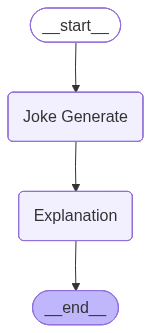

In [6]:
from langgraph.checkpoint.memory import InMemorySaver
graph = StateGraph(JokeState)

graph.add_node("Joke Generate", generate_joke)
graph.add_node("Explanation", explanation_joke)

graph.add_edge(START, "Joke Generate")
graph.add_edge("Joke Generate", "Explanation")
graph.add_edge("Explanation", END)

workflow = graph.compile(checkpointer=InMemorySaver())

workflow



In [7]:
config = {
    "configurable": {
        "thread_id": "chat_1"
    }
}

response = workflow.invoke(
    {
        "topic": "Corporate Office."
    },
    config=config
)

In [8]:
response

{'topic': 'Corporate Office.',
 'joke': 'Why did the scarecrow become a successful corporate employee? \n\nBecause he was outstanding in his field, but still knew how to avoid the "hay"-ments!',
 'explanations': 'This joke employs a play on words and utilizes both literal and figurative language. \n\nThe humor arises from the character of the scarecrow, who is traditionally depicted as a figure placed in fields to deter birds from consuming crops. The punchline, "he was outstanding in his field," serves as a double entendre: it suggests that the scarecrow is physically present in the agricultural field while also implying that he excels in his area of expertise—this could be interpreted as a metaphor for professional competence.\n\nThe second part of the punchline, “but still knew how to avoid the ‘hay’-ments,” relies on a pun involving the word "hay" and the term "payments." Here, the joke implies that the scarecrow, despite being skilled and successful, is clever enough to navigate o

## **Get the state value**

In [9]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Corporate Office.', 'joke': 'Why did the scarecrow become a successful corporate employee? \n\nBecause he was outstanding in his field, but still knew how to avoid the "hay"-ments!', 'explanations': 'This joke employs a play on words and utilizes both literal and figurative language. \n\nThe humor arises from the character of the scarecrow, who is traditionally depicted as a figure placed in fields to deter birds from consuming crops. The punchline, "he was outstanding in his field," serves as a double entendre: it suggests that the scarecrow is physically present in the agricultural field while also implying that he excels in his area of expertise—this could be interpreted as a metaphor for professional competence.\n\nThe second part of the punchline, “but still knew how to avoid the ‘hay’-ments,” relies on a pun involving the word "hay" and the term "payments." Here, the joke implies that the scarecrow, despite being skilled and successful, is clever e

## **Get all history of this chat**

In [10]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'Corporate Office.', 'joke': 'Why did the scarecrow become a successful corporate employee? \n\nBecause he was outstanding in his field, but still knew how to avoid the "hay"-ments!', 'explanations': 'This joke employs a play on words and utilizes both literal and figurative language. \n\nThe humor arises from the character of the scarecrow, who is traditionally depicted as a figure placed in fields to deter birds from consuming crops. The punchline, "he was outstanding in his field," serves as a double entendre: it suggests that the scarecrow is physically present in the agricultural field while also implying that he excels in his area of expertise—this could be interpreted as a metaphor for professional competence.\n\nThe second part of the punchline, “but still knew how to avoid the ‘hay’-ments,” relies on a pun involving the word "hay" and the term "payments." Here, the joke implies that the scarecrow, despite being skilled and successful, is clever 

## **Chat 2**

In [11]:
topic = "Corporate Boss"
config = {
    "configurable": {
        "thread_id": "chat_2"
    }
}

response = workflow.invoke(
    {
        "topic": topic
    },
    config=config
)

In [12]:
response

{'topic': 'Corporate Boss',
 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \nBecause they wanted to take the discussion to the next level!',
 'explanations': 'This joke leverages a pun—specifically, a play on the phrase "take the discussion to the next level," which is commonly used in corporate environments to indicate a desire to elevate the conversation or enhance the quality and depth of the dialogue. The humor arises from the literal interpretation of that phrase. The corporate boss\'s decision to bring a ladder serves as a visual metaphor, suggesting a tangible means of elevating the discussion, which contrasts with the abstract intention typically conveyed in business settings. \n\nWhile the joke employs a clever wordplay that could elicit a chuckle among those familiar with corporate culture, it is relatively light and may not resonate with all audiences. As such, its comedic impact varies based on individual preferences for humor, making it a somewhat sim

In [13]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Corporate Boss', 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \nBecause they wanted to take the discussion to the next level!', 'explanations': 'This joke leverages a pun—specifically, a play on the phrase "take the discussion to the next level," which is commonly used in corporate environments to indicate a desire to elevate the conversation or enhance the quality and depth of the dialogue. The humor arises from the literal interpretation of that phrase. The corporate boss\'s decision to bring a ladder serves as a visual metaphor, suggesting a tangible means of elevating the discussion, which contrasts with the abstract intention typically conveyed in business settings. \n\nWhile the joke employs a clever wordplay that could elicit a chuckle among those familiar with corporate culture, it is relatively light and may not resonate with all audiences. As such, its comedic impact varies based on individual preferences for humor, makin

In [14]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Corporate Boss', 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \nBecause they wanted to take the discussion to the next level!', 'explanations': 'This joke leverages a pun—specifically, a play on the phrase "take the discussion to the next level," which is commonly used in corporate environments to indicate a desire to elevate the conversation or enhance the quality and depth of the dialogue. The humor arises from the literal interpretation of that phrase. The corporate boss\'s decision to bring a ladder serves as a visual metaphor, suggesting a tangible means of elevating the discussion, which contrasts with the abstract intention typically conveyed in business settings. \n\nWhile the joke employs a clever wordplay that could elicit a chuckle among those familiar with corporate culture, it is relatively light and may not resonate with all audiences. As such, its comedic impact varies based on individual preferences for humor, maki

## **Time Travel**

In [15]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [16]:
import time
def step_1(state: CrashState) -> CrashState:
    print("Step -1-")
    return {
        "step1": "done", "input": state["input"]
    }

def step_2(state: CrashState) -> CrashState:
    print("Its hanging now...and interrupt by user...")

    time.sleep(20)

    return {
        "step2": "done"
    }

def step_3(state: CrashState) -> CrashState:
    print("Step -3-")
    return {
        "step3": "done"
    }

## **Build the graph now**

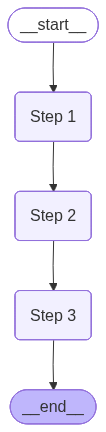

In [17]:
graph = StateGraph(CrashState)
graph.add_node("Step 1", step_1)
graph.add_node("Step 2", step_2)
graph.add_node("Step 3", step_3)

graph.add_edge(START, "Step 1")
graph.add_edge("Step 1", "Step 2")
graph.add_edge("Step 2", "Step 3")
graph.add_edge("Step 3", END)   

from langgraph.checkpoint.memory import InMemorySaver
workflow = graph.compile(checkpointer=InMemorySaver())  
workflow

In [25]:
## my main goal is to test crash recovery here
config = {
    "configurable": {
        "thread_id": "crash_test_2"
    }
}   

In [26]:
try:
    print("Running the graph and its manually interupt by step 2.")
    workflow.invoke({"input": "Start executions."}, config=config)

except KeyboardInterrupt:
    print("Kernel manually interrupt... and its crash")

Running the graph and its manually interupt by step 2.
Step -1-
Its hanging now...and interrupt by user...
Kernel manually interrupt... and its crash


In [27]:
workflow.get_state(config=config)

StateSnapshot(values={'input': 'Start executions.', 'step1': 'done'}, next=('Step 2',), config={'configurable': {'thread_id': 'crash_test_2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f1b05-cf49-6947-8001-4772a6378824'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-01-15T01:20:22.455705+00:00', parent_config={'configurable': {'thread_id': 'crash_test_2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f1b05-cf45-6927-8000-0c235d7b3e21'}}, tasks=(PregelTask(id='1e5d4509-da5f-d4ea-0e71-8f282db06989', name='Step 2', path=('__pregel_pull', 'Step 2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [28]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'Start executions.', 'step1': 'done'}, next=('Step 2',), config={'configurable': {'thread_id': 'crash_test_2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f1b05-cf49-6947-8001-4772a6378824'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-01-15T01:20:22.455705+00:00', parent_config={'configurable': {'thread_id': 'crash_test_2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f1b05-cf45-6927-8000-0c235d7b3e21'}}, tasks=(PregelTask(id='1e5d4509-da5f-d4ea-0e71-8f282db06989', name='Step 2', path=('__pregel_pull', 'Step 2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'Start executions.'}, next=('Step 1',), config={'configurable': {'thread_id': 'crash_test_2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f1b05-cf45-6927-8000-0c235d7b3e21'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-15T01:20:22.454063+00:00', parent_config={'configurable': {'thread_id': 

## **Resume the graph state**

In [29]:
final_state = workflow.invoke(None, config=config)
final_state

Its hanging now...and interrupt by user...
Step -3-


{'input': 'Start executions.',
 'step1': 'done',
 'step2': 'done',
 'step3': 'done'}